Benchmark Xiangqi bots: heuristic vs ml_only vs hybrid

Imports

In [23]:
from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

Find repo and import backend

In [24]:
def find_repo_root():
    cwd = Path.cwd().resolve()
    for p in [cwd] + list(cwd.parents):
        if (p / "backend" / "src").exists():
            return p
    raise FileNotFoundError("Không tìm thấy repo root")

REPO_ROOT = find_repo_root()
BACKEND_DIR = REPO_ROOT / "backend"
ML_DIR = BACKEND_DIR / "ml"

if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from src.board import Board
from src.ai_engine import AIEngine
from src.custom_evaluators import (
    HeuristicEvaluatorWrapper,
    MLEvaluatorWrapper,
    HybridEvaluatorWrapper,
)

Config

In [25]:
from pathlib import Path

ML_DIR = Path.cwd().resolve()
PROCESSED_DIR = ML_DIR / "processed" / "heuristic_label"

X_PATH = PROCESSED_DIR / "xiangqi_X.npy"
Y_PATH = PROCESSED_DIR / "xiangqi_y.npy"
MODEL_PATH = PROCESSED_DIR / "model.pt"

BATCH_SIZE = 128
EPOCHS = 15
LR = 1e-3
VAL_RATIO = 0.2
MODEL_TYPE = "cnn"   # "mlp" or "cnn"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NUM_GAMES_PER_MATCHUP = 20
SEARCH_DEPTH = 2
TIME_LIMIT = 0.2
HYBRID_ALPHA = 0.5
MAX_PLIES_PER_GAME = 200
RESULTS_DIR = ML_DIR / "benchmark_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("DEVICE =", DEVICE)
print("X exists?", X_PATH.exists())
print("Y exists?", Y_PATH.exists())

DEVICE = cpu
X exists? True
Y exists? True


In [26]:
class MLPValueNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

class CNNValueNet(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 10 * 9, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

Load model

In [27]:
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model_type = checkpoint["model_type"]
input_shape = checkpoint["input_shape"]

if model_type == "mlp":
    input_dim = int(np.prod(input_shape))
    model = MLPValueNet(input_dim)
else:
    in_channels = input_shape[0]
    model = CNNValueNet(in_channels)

model.load_state_dict(checkpoint["state_dict"])
model = model.to(DEVICE)
model.eval()

print("Loaded model type:", model_type)
print("Input shape:", input_shape)

Loaded model type: mlp
Input shape: (15, 10, 9)


Tạo AI engine

In [28]:
def create_engine(board, bot_name, model=None, model_type="mlp", device="cpu",
                  search_depth=2, time_limit=0.2, alpha=0.5):
    if bot_name == "heuristic":
        evaluator = HeuristicEvaluatorWrapper(board)

    elif bot_name == "ml_only":
        evaluator = MLEvaluatorWrapper(
            board=board,
            model=model,
            model_type=model_type,
            device=device,
        )

    elif bot_name == "hybrid":
        evaluator = HybridEvaluatorWrapper(
            board=board,
            model=model,
            model_type=model_type,
            device=device,
            alpha=alpha,
        )

    else:
        raise ValueError(f"Unknown bot_name: {bot_name}")

    return AIEngine(
        board,
        max_depth=search_depth,
        time_limit=time_limit,
        evaluator=evaluator,
    )

select move bằng cùng minimax

In [29]:
def select_move_fair(board_obj, side, bot_name, model=None, model_type="mlp",
                     device="cpu", search_depth=2, time_limit=0.2, alpha=0.5):
    engine = create_engine(
        board_obj,
        bot_name=bot_name,
        model=model,
        model_type=model_type,
        device=device,
        search_depth=search_depth,
        time_limit=time_limit,
        alpha=alpha,
    )
    return engine.get_best_move(is_red_turn=(side == "red"))

play game

In [30]:
def opposite_side(side):
    return "black" if side == "red" else "red"

def play_one_game_fair(bot_red, bot_black, model, model_type, device,
                       max_plies=200, search_depth=2, time_limit=0.2, alpha=0.5):
    board = Board()
    side_to_move = "red"

    move_times = {"red": [], "black": []}

    for ply in range(max_plies):
        result = board.is_game_over()
        if result == "red_win":
            return {
                "result": "red",
                "num_plies": ply,
                "avg_time_red": np.mean(move_times["red"]) if move_times["red"] else 0.0,
                "avg_time_black": np.mean(move_times["black"]) if move_times["black"] else 0.0,
            }
        elif result == "black_win":
            return {
                "result": "black",
                "num_plies": ply,
                "avg_time_red": np.mean(move_times["red"]) if move_times["red"] else 0.0,
                "avg_time_black": np.mean(move_times["black"]) if move_times["black"] else 0.0,
            }

        bot_name = bot_red if side_to_move == "red" else bot_black

        t0 = time.perf_counter()
        move = select_move_fair(
            board,
            side_to_move,
            bot_name=bot_name,
            model=model,
            model_type=model_type,
            device=device,
            search_depth=search_depth,
            time_limit=time_limit,
            alpha=alpha,
        )
        dt = time.perf_counter() - t0
        move_times[side_to_move].append(dt)

        if move is None:
            return {
                "result": opposite_side(side_to_move),
                "num_plies": ply,
                "avg_time_red": np.mean(move_times["red"]) if move_times["red"] else 0.0,
                "avg_time_black": np.mean(move_times["black"]) if move_times["black"] else 0.0,
            }

        board.move_piece(*move)
        side_to_move = opposite_side(side_to_move)

    return {
        "result": "draw",
        "num_plies": max_plies,
        "avg_time_red": np.mean(move_times["red"]) if move_times["red"] else 0.0,
        "avg_time_black": np.mean(move_times["black"]) if move_times["black"] else 0.0,
    }

Run one matchup

In [31]:
def run_matchup(bot_a: str, bot_b: str, model, model_type, device, num_games=20,
                search_depth=2, time_limit=0.2, alpha=0.5):
    records = []

    for i in range(num_games):
        if i % 2 == 0:
            bot_red = bot_a
            bot_black = bot_b
        else:
            bot_red = bot_b
            bot_black = bot_a

        game_info = play_one_game_fair(
            bot_red,
            bot_black,
            model=model,
            model_type=model_type,
            device=device,
            max_plies=MAX_PLIES_PER_GAME,
            search_depth=search_depth,
            time_limit=time_limit,
            alpha=alpha,
        )

        result = game_info["result"]

        if result == "red":
            winner_bot = bot_red
        elif result == "black":
            winner_bot = bot_black
        else:
            winner_bot = "draw"

        records.append({
            "game_idx": i,
            "bot_a": bot_a,
            "bot_b": bot_b,
            "bot_red": bot_red,
            "bot_black": bot_black,
            "result_side": result,
            "winner_bot": winner_bot,
            "num_plies": game_info["num_plies"],
            "avg_time_red": game_info["avg_time_red"],
            "avg_time_black": game_info["avg_time_black"],
        })

        print(
            f"[{i+1}/{num_games}] "
            f"{bot_red} (red) vs {bot_black} (black) -> winner: {winner_bot}, "
            f"plies={game_info['num_plies']}"
        )

    return pd.DataFrame(records)

Summary helpers

In [32]:
def summarize_matchup(df: pd.DataFrame, bot_a: str, bot_b: str):
    wins_a = (df["winner_bot"] == bot_a).sum()
    wins_b = (df["winner_bot"] == bot_b).sum()
    draws = (df["winner_bot"] == "draw").sum()
    total = len(df)

    score_a = (wins_a + 0.5 * draws) / total
    score_b = (wins_b + 0.5 * draws) / total

    summary = {
        "bot_a": bot_a,
        "bot_b": bot_b,
        "games": total,
        "wins_a": wins_a,
        "wins_b": wins_b,
        "draws": draws,
        "score_a": score_a,
        "score_b": score_b,
        "avg_plies": df["num_plies"].mean(),
        "avg_time_red": df["avg_time_red"].mean(),
        "avg_time_black": df["avg_time_black"].mean(),
    }
    return pd.DataFrame([summary])

Run benchmarks

In [33]:
all_matchups = [
    ("heuristic", "ml_only"),
    ("heuristic", "hybrid"),
    ("ml_only", "hybrid"),
]

all_results = []
all_summaries = []

for bot_a, bot_b in all_matchups:
    print("=" * 80)
    print(f"Running matchup: {bot_a} vs {bot_b}")
    df_match = run_matchup(
        bot_a,
        bot_b,
        model=model,
        model_type=model_type,
        device=DEVICE,
        num_games=NUM_GAMES_PER_MATCHUP,
        search_depth=SEARCH_DEPTH,
        time_limit=TIME_LIMIT,
        alpha=HYBRID_ALPHA,
    )
    summary = summarize_matchup(df_match, bot_a, bot_b)

    all_results.append(df_match)
    all_summaries.append(summary)

results_df = pd.concat(all_results, ignore_index=True)
summary_df = pd.concat(all_summaries, ignore_index=True)

display(summary_df)

Running matchup: heuristic vs ml_only
[1/20] heuristic (red) vs ml_only (black) -> winner: heuristic, plies=25
[2/20] ml_only (red) vs heuristic (black) -> winner: heuristic, plies=6
[3/20] heuristic (red) vs ml_only (black) -> winner: heuristic, plies=25
[4/20] ml_only (red) vs heuristic (black) -> winner: heuristic, plies=6
[5/20] heuristic (red) vs ml_only (black) -> winner: heuristic, plies=25
[6/20] ml_only (red) vs heuristic (black) -> winner: heuristic, plies=6
[7/20] heuristic (red) vs ml_only (black) -> winner: heuristic, plies=25
[8/20] ml_only (red) vs heuristic (black) -> winner: heuristic, plies=6
[9/20] heuristic (red) vs ml_only (black) -> winner: heuristic, plies=25
[10/20] ml_only (red) vs heuristic (black) -> winner: heuristic, plies=6
[11/20] heuristic (red) vs ml_only (black) -> winner: heuristic, plies=17
[12/20] ml_only (red) vs heuristic (black) -> winner: heuristic, plies=0
[13/20] heuristic (red) vs ml_only (black) -> winner: heuristic, plies=9
[14/20] ml_only 

,bot_a,bot_b,games,wins_a,wins_b,draws,score_a,score_b,avg_plies,avg_time_red,avg_time_black
0,heuristic,ml_only,20,20,0,0,1.000,0.000,9.80,0.143947,0.113814
1,heuristic,hybrid,20,11,0,9,0.775,0.225,104.00,0.134145,0.079897
2,ml_only,hybrid,20,7,13,0,0.350,0.650,4.85,0.199503,0.080435


Save CSV

In [34]:
results_csv = RESULTS_DIR / "benchmark_games.csv"
summary_csv = RESULTS_DIR / "benchmark_summary.csv"

results_df.to_csv(results_csv, index=False)
summary_df.to_csv(summary_csv, index=False)

print("Saved game results to:", results_csv)
print("Saved summary to:", summary_csv)

Saved game results to: C:\co-tuong-ai\backend\ml\benchmark_results\benchmark_games.csv
Saved summary to: C:\co-tuong-ai\backend\ml\benchmark_results\benchmark_summary.csv


Plot score rates

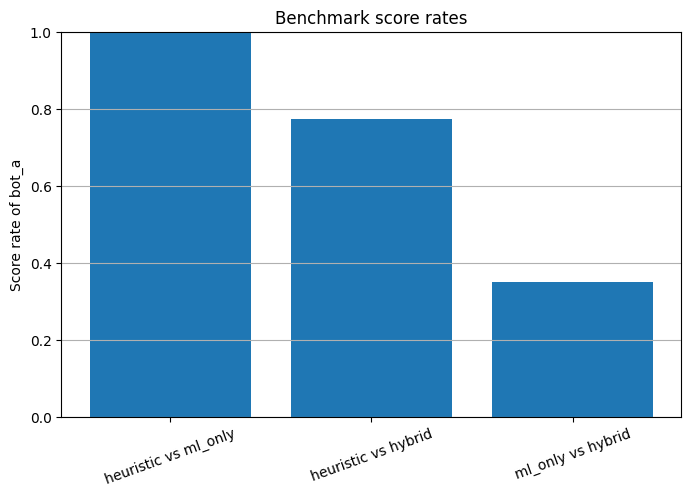

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
labels = [f"{row['bot_a']} vs {row['bot_b']}" for _, row in summary_df.iterrows()]
scores = summary_df["score_a"].values

plt.bar(labels, scores)
plt.ylim(0, 1)
plt.ylabel("Score rate of bot_a")
plt.title("Benchmark score rates")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

Display detailed results

In [40]:
display(results_df.head(20))
display(summary_df)

,game_idx,bot_a,bot_b,bot_red,bot_black,result_side,winner_bot,num_plies,avg_time_red,avg_time_black
0,0,heuristic,ml_only,heuristic,ml_only,red,heuristic,25,0.068429,0.200641
1,1,heuristic,ml_only,ml_only,heuristic,black,heuristic,6,0.200224,0.052459
2,2,heuristic,ml_only,heuristic,ml_only,red,heuristic,25,0.056188,0.200672
3,3,heuristic,ml_only,ml_only,heuristic,black,heuristic,6,0.198257,0.057090
4,4,heuristic,ml_only,heuristic,ml_only,red,heuristic,25,0.057661,0.200126
5,5,heuristic,ml_only,ml_only,heuristic,black,heuristic,6,0.200662,0.054737
6,6,heuristic,ml_only,heuristic,ml_only,red,heuristic,25,0.055873,0.194885
7,7,heuristic,ml_only,ml_only,heuristic,black,heuristic,6,0.200094,0.057016
8,8,heuristic,ml_only,heuristic,ml_only,red,heuristic,25,0.057436,0.200364
9,9,heuristic,ml_only,ml_only,heuristic,black,heuristic,6,0.201814,0.057707


,bot_a,bot_b,games,wins_a,wins_b,draws,score_a,score_b,avg_plies,avg_time_red,avg_time_black
0,heuristic,ml_only,20,20,0,0,1.000,0.000,9.80,0.143947,0.113814
1,heuristic,hybrid,20,11,0,9,0.775,0.225,104.00,0.134145,0.079897
2,ml_only,hybrid,20,7,13,0,0.350,0.650,4.85,0.199503,0.080435


Nếu heuristic vs ml_only
và score_a của heuristic > 0.5 → heuristic mạnh hơn ml_only

Nếu heuristic vs hybrid
và hybrid thắng nhiều hơn → hybrid đang đáng dùng hơn

Nếu ml_only vs hybrid
và hybrid tốt hơn → model chưa đủ mạnh để thay hẳn heuristic, nên kết hợp cả 2